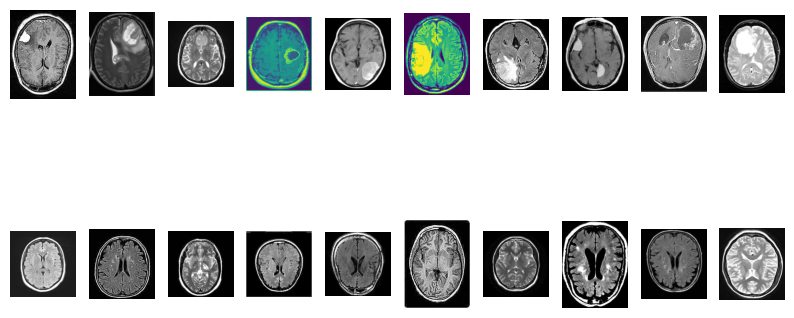

In [17]:
from PIL import Image
import matplotlib.pyplot as plt
from pathlib import Path
import sys

sys.path.append("..")

image_path_yes = Path("/Users/kevinlenguyen/dcgan-brain-mri-synthesis-/data/yes")
image_path_no = Path("/Users/kevinlenguyen/dcgan-brain-mri-synthesis-/data/no")
images_yes = []
images_no = []

for img_path in image_path_yes.glob("*.jpg"):
    img = Image.open(img_path)
    images_yes.append(img)

for img_path in image_path_no.glob("*.jpg"):
    img = Image.open(img_path)
    images_no.append(img)

plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 10, i + 1)
    plt.imshow(images_yes[i])
    plt.axis('off')
    plt.subplot(2, 10, i + 11)
    plt.imshow(images_no[i])
    plt.axis('off')

plt.show()

In [8]:
for img in images_yes:
    print(img.size, img.mode)

(223, 303) RGB
(272, 350) RGB
(225, 225) RGB
(319, 360) L
(591, 650) RGB
(240, 300) L
(314, 340) RGB
(212, 237) RGB
(273, 318) RGB
(288, 340) RGB
(236, 236) RGB
(512, 512) RGB
(512, 512) RGB
(294, 355) RGB
(911, 938) RGB
(216, 234) RGB
(272, 350) RGB
(232, 309) RGB
(273, 318) RGB
(276, 323) RGB
(180, 218) RGB
(290, 355) RGB
(864, 938) RGB
(254, 325) RGB
(303, 354) RGB
(300, 347) RGB
(249, 269) RGB
(911, 938) RGB
(278, 324) RGB
(450, 446) RGB
(200, 210) RGB
(283, 295) RGB
(630, 630) RGB
(256, 256) RGB
(400, 369) RGB
(204, 251) RGB
(205, 243) RGB
(241, 286) RGB
(1061, 1280) RGB
(283, 357) RGB
(211, 239) RGB
(283, 357) RGB
(450, 446) RGB
(272, 277) RGB
(189, 173) RGB
(630, 630) RGB
(276, 323) RGB
(260, 331) RGB
(197, 256) RGB
(864, 938) RGB
(292, 349) RGB
(526, 555) RGB
(180, 218) RGB
(512, 512) RGB
(283, 295) RGB
(194, 260) RGB
(278, 324) RGB
(272, 355) RGB
(213, 236) RGB
(213, 236) RGB
(300, 347) RGB
(279, 344) RGB
(241, 286) RGB
(276, 323) RGB
(310, 380) RGB
(230, 219) RGB
(180, 218) R

In [9]:
for img in images_no:
    print(img.size, img.mode)

(442, 442) RGB
(218, 231) RGB
(225, 225) RGB
(225, 225) RGB
(227, 222) RGB
(194, 259) RGB
(225, 225) RGB
(150, 198) RGB
(218, 231) RGB
(214, 236) RGB
(225, 225) RGB
(300, 168) RGB
(206, 244) RGB
(227, 222) RGB
(201, 250) RGB
(411, 501) RGB
(225, 225) RGB
(201, 251) RGB
(192, 192) RGB
(300, 168) RGB
(630, 630) RGB
(512, 512) RGB
(206, 244) RGB
(200, 252) RGB
(207, 243) RGB
(228, 221) RGB
(225, 225) RGB
(225, 225) RGB
(512, 512) RGB
(173, 201) RGB
(275, 183) RGB
(225, 225) RGB
(630, 630) RGB
(214, 236) RGB
(228, 221) RGB
(208, 242) RGB
(300, 168) RGB
(215, 234) RGB
(208, 242) RGB
(236, 213) RGB
(300, 168) RGB
(225, 225) RGB
(208, 242) RGB
(356, 474) RGB
(228, 221) RGB
(194, 259) RGB
(504, 540) RGB
(468, 444) RGB
(208, 242) RGB
(642, 361) RGB
(225, 225) RGB
(225, 225) RGB
(225, 225) RGB
(207, 243) RGB
(200, 252) RGB
(225, 225) RGB
(235, 214) RGB
(200, 252) RGB
(225, 225) RGB
(218, 231) RGB
(300, 168) RGB
(235, 214) RGB
(642, 361) RGB
(227, 222) RGB
(236, 295) RGB
(236, 218) RGB
(300, 168)

In [10]:
print(len(images_yes), len(images_no))

1500 1500


In [ ]:
for img_path in Path("data/yes").glob("*.jpg"):
    try:
        Image.open(img_path).verify()
    except Exception as e:
        print(f"Kaputt: {img_path}, Fehler: {e}")

In [13]:
import numpy as np
arr = np.array(images_yes[0])
print(arr.min(), arr.max(), arr.dtype)

0 255 uint8


In [29]:
from src.data import preprocess_images

processed_images = preprocess_images(Path("../data/yes"), size=(128, 128))

print("Images before preprocessing:")
for img in images_yes:
    print(img.size, img.mode)

print("Images after preprocessing:")
print(processed_images.shape)
print(processed_images.dtype, processed_images.size, processed_images.ndim)

Images before preprocessing:
(223, 303) RGB
(272, 350) RGB
(225, 225) RGB
(319, 360) L
(591, 650) RGB
(240, 300) L
(314, 340) RGB
(212, 237) RGB
(273, 318) RGB
(288, 340) RGB
(236, 236) RGB
(512, 512) RGB
(512, 512) RGB
(294, 355) RGB
(911, 938) RGB
(216, 234) RGB
(272, 350) RGB
(232, 309) RGB
(273, 318) RGB
(276, 323) RGB
(180, 218) RGB
(290, 355) RGB
(864, 938) RGB
(254, 325) RGB
(303, 354) RGB
(300, 347) RGB
(249, 269) RGB
(911, 938) RGB
(278, 324) RGB
(450, 446) RGB
(200, 210) RGB
(283, 295) RGB
(630, 630) RGB
(256, 256) RGB
(400, 369) RGB
(204, 251) RGB
(205, 243) RGB
(241, 286) RGB
(1061, 1280) RGB
(283, 357) RGB
(211, 239) RGB
(283, 357) RGB
(450, 446) RGB
(272, 277) RGB
(189, 173) RGB
(630, 630) RGB
(276, 323) RGB
(260, 331) RGB
(197, 256) RGB
(864, 938) RGB
(292, 349) RGB
(526, 555) RGB
(180, 218) RGB
(512, 512) RGB
(283, 295) RGB
(194, 260) RGB
(278, 324) RGB
(272, 355) RGB
(213, 236) RGB
(213, 236) RGB
(300, 347) RGB
(279, 344) RGB
(241, 286) RGB
(276, 323) RGB
(310, 380) RG

Images after preprocessing:
